# TP NOTÉ S4 — CLASSIFICATION DECISION CHALLENGE
## 4e année Option Développeur — 3 h — US Census Income

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.


## Mission — 5 pts

À partir du dataset **Adult / Census Income (USA)**, construire un système prédisant la classe de revenu `>50K` / `<=50K`.

Votre travail ne sera pas évalué uniquement sur l'accuracy. Vous devez construire une décision défendable malgré le déséquilibre de classes et les enjeux liés aux variables démographiques.

In [1]:
# Votre travail expérimental ici
from pathlib import Path
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

WINDOWS_DATA_DIR = Path(r"C:\Users\brani\Documents\trining\data")
candidate_dirs = [
    WINDOWS_DATA_DIR,
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd(),
]
DATA_DIR = next((p for p in candidate_dirs if (p / "adult.data").exists()), None)
if DATA_DIR is None:
    checked = "\n - ".join(str(p) for p in candidate_dirs)
    raise FileNotFoundError(
        "adult.data est introuvable. Décompressez adult.zip dans le dossier data.\n"
        f"Dossiers vérifiés :\n - {checked}"
    )

DEV_PATH = DATA_DIR / "adult.data"
TEST_PATH = DATA_DIR / "adult.test"  # chemin seulement : le fichier sera lu en section 6

dev_raw = pd.read_csv(
    DEV_PATH,
    names=COLUMNS,
    sep=",",
    skipinitialspace=True,
    na_values="?",
)
dev_raw["income"] = dev_raw["income"].str.strip().str.rstrip(".")
if not set(dev_raw["income"].dropna().unique()).issubset({"<=50K", ">50K"}):
    raise ValueError("Libellés de cible inattendus dans adult.data")

print(f"Python : {platform.python_version()}")
print(f"Dossier de données retenu : {DATA_DIR.resolve()}")
print(f"Jeu de développement chargé : {dev_raw.shape[0]:,} lignes × {dev_raw.shape[1]} colonnes")
print("Le fichier adult.test n'a pas encore été lu.")
display(dev_raw.head())

Python : 3.12.14
Dossier de données retenu : /workspace/scratch/87e58d605725/TP_S4_Classification/data
Jeu de développement chargé : 32,561 lignes × 15 colonnes
Le fichier adult.test n'a pas encore été lu.


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Audit & protocole — 15 pts

Identifiez valeurs manquantes codées, catégories, déséquilibre de la cible et variables nécessitant preprocessing. Construisez TRAIN/VALIDATION/TEST sans fuite.

Justifiez ce qui doit être appris sur TRAIN. Donnez une preuve numérique issue de votre pipeline.

Doublons exacts : 24 (0.074 %).
Après suppression : 32,537 lignes (perte de 24 lignes, soit 0.074 %).
Variables numériques : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Variables catégorielles : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Nombre de variables après transformation : 108
Toutes les médianes apprises correspondent à TRAIN : True


,type,NA,% NA,valeurs_uniques,exemple
age,int64,0,0.00,73,39
workclass,object,1836,5.64,8,State-gov
fnlwgt,int64,0,0.00,21648,77516
education,object,0,0.00,16,Bachelors
education_num,int64,0,0.00,16,13
marital_status,object,0,0.00,7,Never-married
occupation,object,1843,5.66,14,Adm-clerical
relationship,object,0,0.00,6,Not-in-family
race,object,0,0.00,5,White
sex,object,0,0.00,2,Male


,effectif,proportion_%
income,,
<=50K,24720,75.92
>50K,7841,24.08


,jeu,lignes,positifs,% positifs
0,TRAIN,26029,6271,24.09
1,VALIDATION,6508,1568,24.09


,variable,médiane_apprise_pipeline,médiane_TRAIN,médiane_VALIDATION_non_utilisée,preuve_fit_train
0,age,37.0,37.0,37.0,True
1,fnlwgt,178142.0,178142.0,179486.0,True
2,education_num,10.0,10.0,10.0,True
3,capital_gain,0.0,0.0,0.0,True
4,capital_loss,0.0,0.0,0.0,True
5,hours_per_week,40.0,40.0,40.0,True


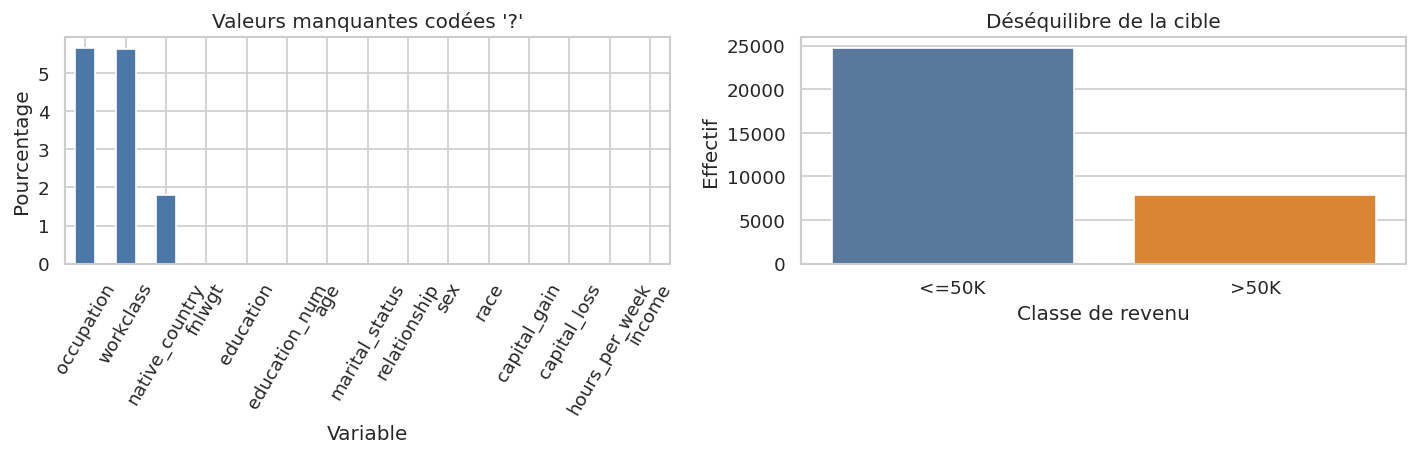

In [2]:
audit = pd.DataFrame({
    "type": dev_raw.dtypes.astype(str),
    "NA": dev_raw.isna().sum(),
    "% NA": (100 * dev_raw.isna().mean()).round(2),
    "valeurs_uniques": dev_raw.nunique(dropna=True),
    "exemple": [next((str(v) for v in dev_raw[c].dropna().head(1)), "—") for c in dev_raw.columns],
})
display(audit)

n_duplicates = int(dev_raw.duplicated().sum())
duplicate_rate = 100 * n_duplicates / len(dev_raw)
print(f"Doublons exacts : {n_duplicates} ({duplicate_rate:.3f} %).")

target_audit = pd.DataFrame({
    "effectif": dev_raw["income"].value_counts(),
    "proportion_%": (100 * dev_raw["income"].value_counts(normalize=True)).round(2),
})
display(target_audit)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(100 * dev_raw.isna().mean()).sort_values(ascending=False).plot.bar(ax=axes[0], color="#4C78A8")
axes[0].set(title="Valeurs manquantes codées '?'", ylabel="Pourcentage", xlabel="Variable")
axes[0].tick_params(axis="x", rotation=60)
sns.countplot(data=dev_raw, x="income", hue="income", legend=False, ax=axes[1], palette=["#4C78A8", "#F58518"])
axes[1].set(title="Déséquilibre de la cible", xlabel="Classe de revenu", ylabel="Effectif")
plt.tight_layout()

# Suppression mesurée des doublons avant toute séparation.
dev = dev_raw.drop_duplicates().reset_index(drop=True)
print(f"Après suppression : {len(dev):,} lignes (perte de {len(dev_raw)-len(dev)} lignes, soit {duplicate_rate:.3f} %).")

X_dev = dev.drop(columns="income")
y_dev = (dev["income"] == ">50K").astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MANQUANT")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

split_proof = pd.DataFrame({
    "jeu": ["TRAIN", "VALIDATION"],
    "lignes": [len(X_train), len(X_val)],
    "positifs": [int(y_train.sum()), int(y_val.sum())],
    "% positifs": [100*y_train.mean(), 100*y_val.mean()],
}).round(2)
display(split_proof)

# Preuve numérique : ajustement témoin uniquement sur TRAIN.
proof_preprocessor = clone(preprocessor).fit(X_train)
learned_medians = proof_preprocessor.named_transformers_["num"].named_steps["imputer"].statistics_
leakage_proof = pd.DataFrame({
    "variable": numeric_features,
    "médiane_apprise_pipeline": learned_medians,
    "médiane_TRAIN": X_train[numeric_features].median().values,
    "médiane_VALIDATION_non_utilisée": X_val[numeric_features].median().values,
})
leakage_proof["preuve_fit_train"] = np.isclose(
    leakage_proof["médiane_apprise_pipeline"], leakage_proof["médiane_TRAIN"]
)
display(leakage_proof)

n_encoded = proof_preprocessor.transform(X_train.iloc[:5]).shape[1]
print(f"Variables numériques : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")
print(f"Nombre de variables après transformation : {n_encoded}")
print("Toutes les médianes apprises correspondent à TRAIN :", bool(leakage_proof["preuve_fit_train"].all()))

## Quatre familles obligatoires — 25 pts

Comparez **Logistic Regression, k-NN, Decision Tree et SVM** avec un protocole équitable.

Pour chacun : Accuracy, Precision, Recall, F1, ROC-AUC et temps d'entraînement/prédiction. Ne choisissez pas le modèle final à ce stade.

,Accuracy,Precision,Recall,F1,ROC-AUC,Score continu,Seuil défaut,Fit (s),Prédiction (s)
Modèle,,,,,,,,,
Logistic Regression,0.8576,0.7419,0.6269,0.6796,0.9116,probabilité,0.5,0.1600,0.0109
SVM linéaire,0.8574,0.7473,0.6167,0.6758,0.9114,decision_function,0.0,0.2717,0.0134
Decision Tree,0.8608,0.7470,0.6384,0.6884,0.9093,probabilité,0.5,0.3811,0.0242
k-NN,0.8442,0.6993,0.6199,0.6572,0.8966,probabilité,0.5,0.0584,7.6519


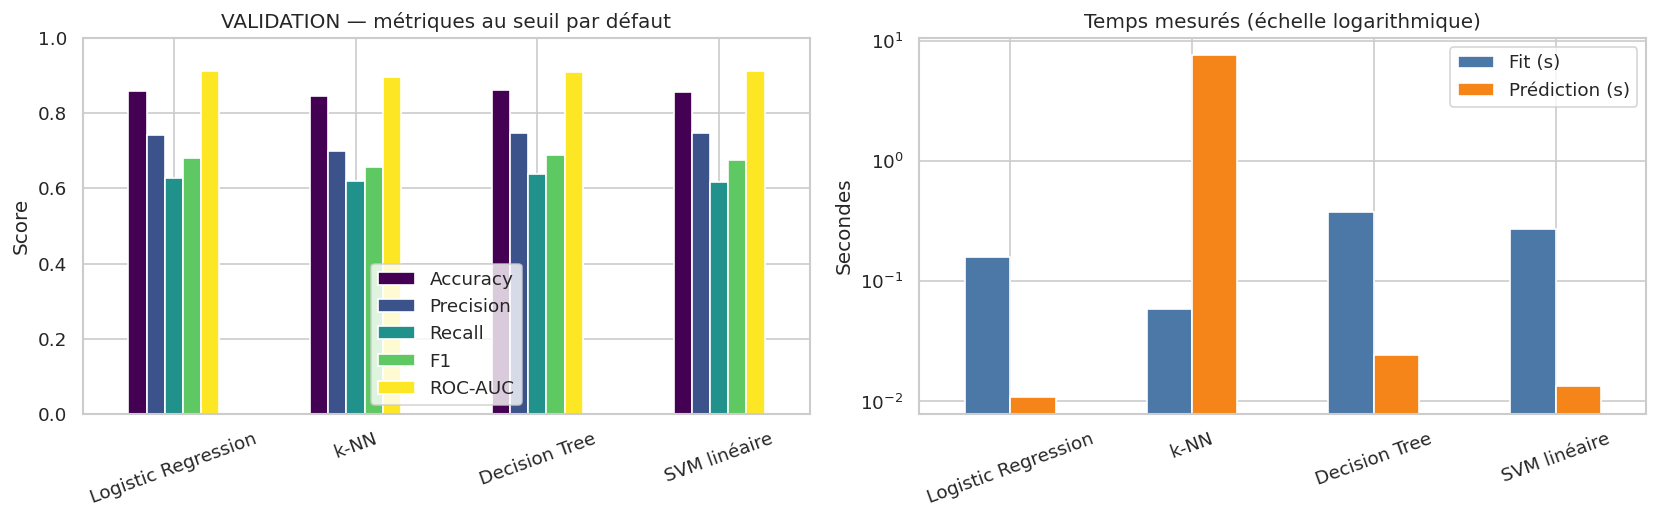

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2500, solver="liblinear", random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE
    ),
    "SVM linéaire": LinearSVC(C=1.0, dual="auto", max_iter=10000, random_state=RANDOM_STATE),
}

def continuous_scores(fitted_pipeline, X):
    """Retourne score continu, type de score et seuil par défaut."""
    if hasattr(fitted_pipeline, "predict_proba"):
        return fitted_pipeline.predict_proba(X)[:, 1], "probabilité", 0.5
    return fitted_pipeline.decision_function(X), "decision_function", 0.0

def metric_row(y_true, y_pred, scores):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
    }

fitted_models = {}
validation_scores = {}
validation_predictions = {}
rows = []

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", clone(estimator)),
    ])
    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - t0

    t0 = time.perf_counter()
    scores, score_kind, default_threshold = continuous_scores(pipeline, X_val)
    pred = (scores >= default_threshold).astype(int)
    predict_seconds = time.perf_counter() - t0

    row = metric_row(y_val, pred, scores)
    row.update({
        "Modèle": name,
        "Score continu": score_kind,
        "Seuil défaut": default_threshold,
        "Fit (s)": fit_seconds,
        "Prédiction (s)": predict_seconds,
    })
    rows.append(row)
    fitted_models[name] = pipeline
    validation_scores[name] = scores
    validation_predictions[name] = pred

model_results = pd.DataFrame(rows).set_index("Modèle")
display(model_results.round(4).sort_values("ROC-AUC", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
model_results[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot.bar(ax=axes[0], ylim=(0, 1), colormap="viridis")
axes[0].set(title="VALIDATION — métriques au seuil par défaut", ylabel="Score", xlabel="")
axes[0].tick_params(axis="x", rotation=20)
model_results[["Fit (s)", "Prédiction (s)"]].plot.bar(ax=axes[1], logy=True, color=["#4C78A8", "#F58518"])
axes[1].set(title="Temps mesurés (échelle logarithmique)", ylabel="Secondes", xlabel="")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()

## Cost-sensitive decision — 20 pts

Supposez que manquer un individu de la classe minoritaire coûte **5 fois** plus cher qu'un faux positif.

Construisez votre propre coût à partir de la matrice de confusion. Comparez les quatre modèles selon ce coût.

Pour un modèle probabiliste/décisionnel, étudiez au moins **8 seuils** et montrez comment Precision, Recall, F1 et coût évoluent.

Le seuil 0,5 n'est donc pas automatiquement optimal.

Comparaison au seuil par défaut :
Meilleur seuil logistique parmi les 15 étudiés : 0.15
Comparaison après sélection du seuil sur VALIDATION :
Choix figé avant TEST : Logistic Regression, seuil = 0.1500.
Critère de choix : coût VALIDATION minimal, puis F1 en cas d'égalité.


,TN,FP,FN,TP,Coût = FP + 5×FN,Precision,Recall,F1
Modèle,,,,,,,,
Decision Tree,4601,339,567,1001,3174,0.7470,0.6384,0.6884
Logistic Regression,4598,342,585,983,3267,0.7419,0.6269,0.6796
SVM linéaire,4613,327,601,967,3332,0.7473,0.6167,0.6758
k-NN,4522,418,596,972,3398,0.6993,0.6199,0.6572


,Seuil,TN,FP,FN,TP,Coût = FP + 5×FN,Precision,Recall,F1
0,0.05,2527,2413,30,1538,2563,0.3893,0.9809,0.5573
1,0.10,3115,1825,69,1499,2170,0.4510,0.9560,0.6128
2,0.15,3498,1442,105,1463,1967,0.5036,0.9330,0.6541
3,0.20,3754,1186,160,1408,1986,0.5428,0.8980,0.6766
4,0.25,3965,975,229,1339,2120,0.5787,0.8540,0.6899
5,0.30,4155,785,291,1277,2240,0.6193,0.8144,0.7036
6,0.35,4305,635,386,1182,2565,0.6505,0.7538,0.6984
7,0.40,4418,522,459,1109,2817,0.6800,0.7073,0.6933
8,0.45,4517,423,520,1048,3023,0.7124,0.6684,0.6897
9,0.50,4598,342,585,983,3267,0.7419,0.6269,0.6796


,Seuil,TN,FP,FN,TP,Coût = FP + 5×FN,Precision,Recall,F1
Modèle,,,,,,,,,
Logistic Regression,0.1500,3498.0,1442.0,105.0,1463.0,1967.0,0.5036,0.9330,0.6541
SVM linéaire,-0.5794,3528.0,1412.0,116.0,1452.0,1992.0,0.5070,0.9260,0.6552
Decision Tree,0.1500,3509.0,1431.0,127.0,1441.0,2066.0,0.5017,0.9190,0.6491
k-NN,0.2000,3633.0,1307.0,166.0,1402.0,2137.0,0.5175,0.8941,0.6556


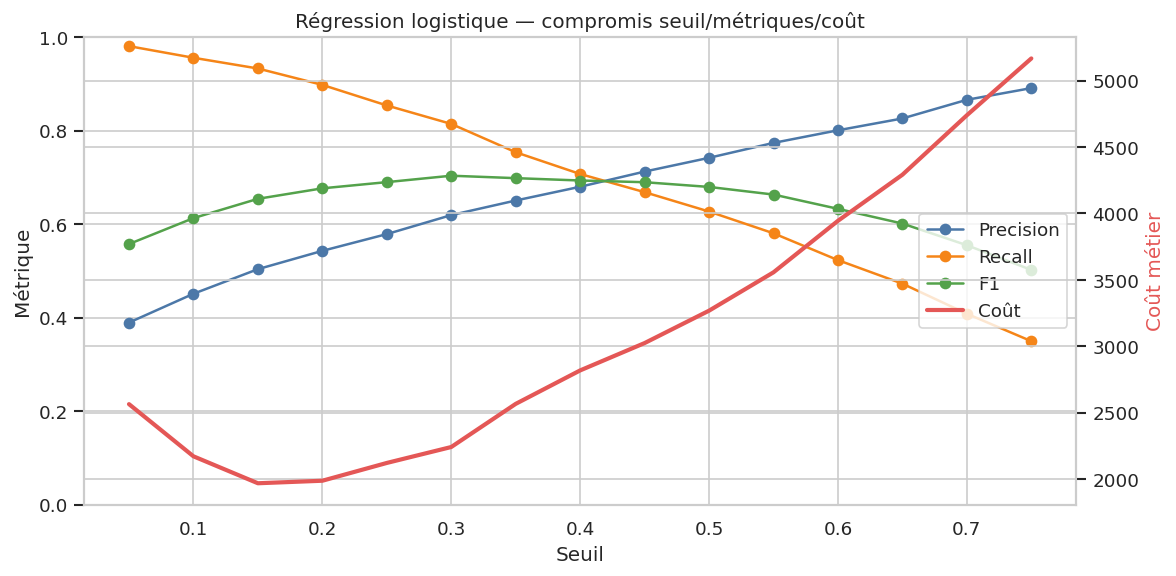

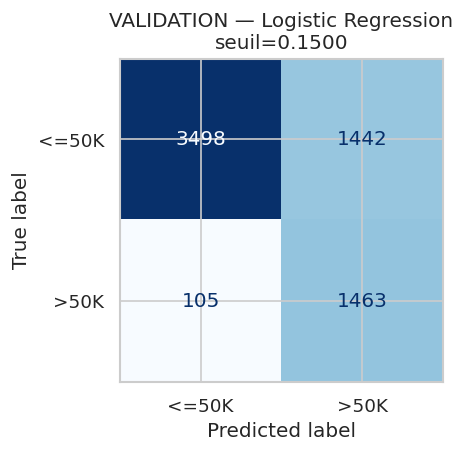

In [4]:
def business_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Coût = FP + 5×FN": int(fp + 5*fn),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
    }

default_cost_rows = []
for name, pred in validation_predictions.items():
    row = {"Modèle": name, **business_metrics(y_val, pred)}
    default_cost_rows.append(row)
default_costs = pd.DataFrame(default_cost_rows).set_index("Modèle").sort_values("Coût = FP + 5×FN")
print("Comparaison au seuil par défaut :")
display(default_costs.round(4))

# Étude détaillée demandée : 15 seuils pour le modèle probabiliste logistique.
logistic_scores = validation_scores["Logistic Regression"]
threshold_rows = []
for threshold in np.arange(0.05, 0.80, 0.05):
    pred = (logistic_scores >= threshold).astype(int)
    threshold_rows.append({"Seuil": threshold, **business_metrics(y_val, pred)})
threshold_study = pd.DataFrame(threshold_rows)
best_logistic_idx = threshold_study["Coût = FP + 5×FN"].idxmin()
display(threshold_study.round(4))
print("Meilleur seuil logistique parmi les 15 étudiés :", round(float(threshold_study.loc[best_logistic_idx, "Seuil"]), 3))

fig, ax1 = plt.subplots(figsize=(10, 5))
for metric, color in [("Precision", "#4C78A8"), ("Recall", "#F58518"), ("F1", "#54A24B")]:
    ax1.plot(threshold_study["Seuil"], threshold_study[metric], marker="o", label=metric, color=color)
ax1.set(xlabel="Seuil", ylabel="Métrique", ylim=(0, 1), title="Régression logistique — compromis seuil/métriques/coût")
ax2 = ax1.twinx()
ax2.plot(threshold_study["Seuil"], threshold_study["Coût = FP + 5×FN"], color="#E45756", linewidth=2.5, label="Coût")
ax2.set_ylabel("Coût métier", color="#E45756")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()

# Optimisation de seuil sur VALIDATION pour chaque famille.
optimized_rows = []
for name, scores in validation_scores.items():
    score_kind = model_results.loc[name, "Score continu"]
    default_threshold = float(model_results.loc[name, "Seuil défaut"])
    if score_kind == "probabilité":
        candidates = np.unique(np.r_[np.linspace(0.05, 0.95, 37), default_threshold])
    else:
        # Les scores SVM ne sont pas des probabilités : grille définie par leurs quantiles.
        candidates = np.unique(np.r_[np.quantile(scores, np.linspace(0.02, 0.98, 49)), default_threshold])

    candidate_rows = []
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        candidate_rows.append({"Seuil": float(threshold), **business_metrics(y_val, pred)})
    search = pd.DataFrame(candidate_rows)
    # Critère principal : coût ; départage : F1 le plus élevé.
    best = search.sort_values(["Coût = FP + 5×FN", "F1"], ascending=[True, False]).iloc[0]
    optimized_rows.append({"Modèle": name, **best.to_dict()})

optimized_costs = (
    pd.DataFrame(optimized_rows)
    .set_index("Modèle")
    .sort_values(["Coût = FP + 5×FN", "F1"], ascending=[True, False])
)
print("Comparaison après sélection du seuil sur VALIDATION :")
display(optimized_costs.round(4))

selected_model_name = optimized_costs.index[0]
selected_threshold = float(optimized_costs.iloc[0]["Seuil"])
selected_val_scores = validation_scores[selected_model_name]
selected_val_pred = (selected_val_scores >= selected_threshold).astype(int)

print(f"Choix figé avant TEST : {selected_model_name}, seuil = {selected_threshold:.4f}.")
print("Critère de choix : coût VALIDATION minimal, puis F1 en cas d'égalité.")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, selected_val_pred, display_labels=["<=50K", ">50K"], cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"VALIDATION — {selected_model_name}\nseuil={selected_threshold:.4f}")
plt.tight_layout()

## Error audit — 15 pts

Analysez au moins **20 erreurs individuelles** de VALIDATION. Comparez FP et FN. Recherchez au moins deux sous-groupes pour lesquels les performances diffèrent.

Vous devez distinguer constat statistique, hypothèse et conclusion. N'inférez pas de causalité.


Performances par sexe :
Performances par race :

CONSTATS STATISTIQUES (VALIDATION)
1. Le modèle produit 1442 FP et 105 FN.
2. Le recall varie de 0.823 (Female) à 0.954 (Male) selon le sexe.
3. Parmi les groupes de race avec au moins 20 positifs réels, le recall varie de 0.818 (Asian-Pac-Islander) à 0.942 (White).

HYPOTHÈSES À TESTER
- Les écarts peuvent être liés aux tailles de groupes et aux distributions différentes d'éducation, profession et heures travaillées.
- Une validation croisée répétée permettrait de vérifier si ces écarts sont stables ou dus au hasard du découpage.

CONCLUSION LIMITÉE
Des écarts de performance sont observés sur cette validation. Ils justifient un audit approfondi, mais ne permettent pas d'inférer une causalité.


,type_erreur,age,workclass,education,occupation,relationship,race,sex,hours_per_week,capital_gain,capital_loss,y_vrai,y_prédit,score,distance_au_seuil
0,FP,42,Private,HS-grad,Machine-op-inspct,Husband,White,Male,40,0,0,0,1,0.1501,0.0001
1,FP,57,Self-emp-not-inc,HS-grad,Exec-managerial,Husband,White,Male,1,0,0,0,1,0.1502,0.0002
2,FP,50,Private,HS-grad,Sales,Not-in-family,White,Male,60,0,0,0,1,0.1506,0.0006
3,FP,28,Private,9th,Protective-serv,Wife,Black,Female,40,0,0,0,1,0.1507,0.0007
4,FP,62,NaN,HS-grad,NaN,Husband,White,Male,24,0,0,0,1,0.1510,0.0010
5,FP,30,Private,HS-grad,Machine-op-inspct,Husband,White,Male,40,0,0,0,1,0.1511,0.0011
6,FP,22,Private,Bachelors,Prof-specialty,Not-in-family,White,Male,50,0,0,0,1,0.1511,0.0011
7,FP,39,Private,HS-grad,Handlers-cleaners,Husband,White,Male,40,0,0,0,1,0.1513,0.0013
8,FP,51,Private,9th,Sales,Husband,White,Male,40,0,0,0,1,0.1514,0.0014
9,FP,29,Private,Bachelors,Tech-support,Not-in-family,White,Male,40,0,0,0,1,0.1514,0.0014


,sex,support,positifs_réels,taux_positif_réel,Accuracy,Precision,Recall,F1,taux_erreur
0,Male,4378,1314,0.3001,0.6969,0.4974,0.9543,0.6540,0.3031
1,Female,2130,254,0.1192,0.8967,0.5443,0.8228,0.6552,0.1033


,race,support,positifs_réels,taux_positif_réel,Accuracy,Precision,Recall,F1,taux_erreur
0,White,5525,1413,0.2557,0.7502,0.5063,0.9420,0.6586,0.2498
1,Black,644,87,0.1351,0.8618,0.4937,0.8966,0.6367,0.1382
2,Asian-Pac-Islander,208,55,0.2644,0.7163,0.4787,0.8182,0.6040,0.2837
3,Amer-Indian-Eskimo,66,9,0.1364,0.8030,0.3571,0.5556,0.4348,0.1970
4,Other,65,4,0.0615,0.9077,0.4000,1.0000,0.5714,0.0923


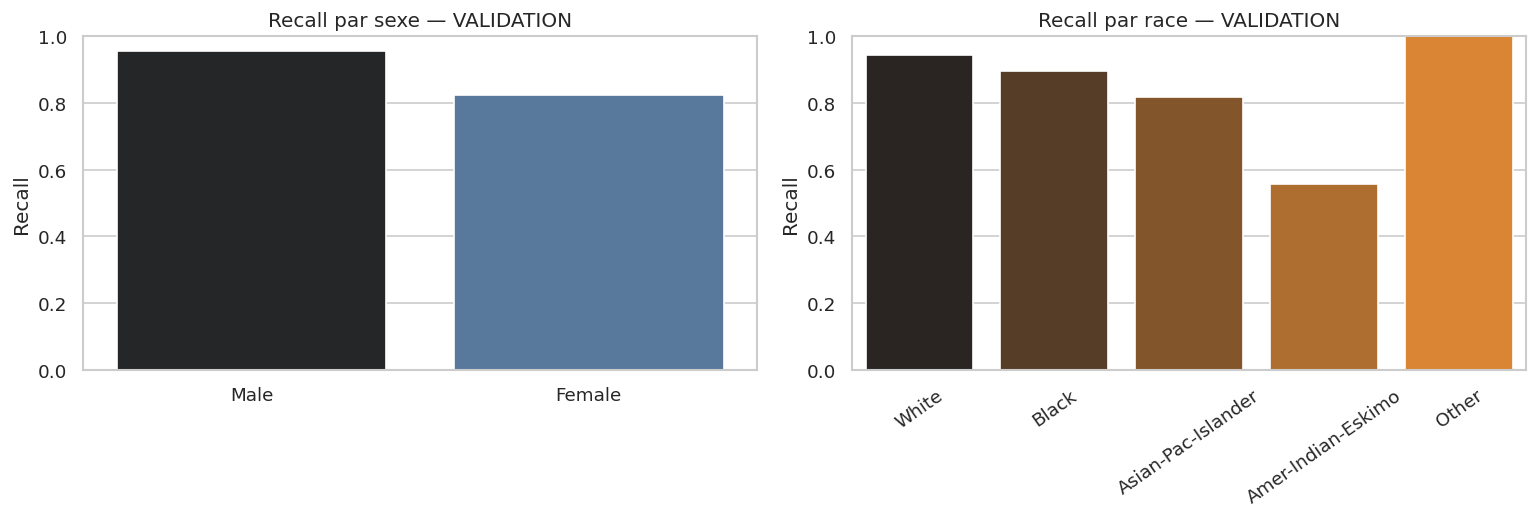

In [5]:
# Votre travail expérimental ici
error_audit = X_val.reset_index(drop=True).copy()
error_audit["y_vrai"] = y_val.reset_index(drop=True)
error_audit["y_prédit"] = selected_val_pred
error_audit["score"] = selected_val_scores
error_audit["distance_au_seuil"] = np.abs(selected_val_scores - selected_threshold)
error_audit["type_erreur"] = np.select(
    [
        (error_audit["y_vrai"] == 0) & (error_audit["y_prédit"] == 1),
        (error_audit["y_vrai"] == 1) & (error_audit["y_prédit"] == 0),
    ],
    ["FP", "FN"],
    default="correct",
)

fp_examples = error_audit.query("type_erreur == 'FP'").nsmallest(10, "distance_au_seuil")
fn_examples = error_audit.query("type_erreur == 'FN'").nsmallest(10, "distance_au_seuil")
twenty_errors = pd.concat([fp_examples, fn_examples], ignore_index=True)
shown_columns = [
    "type_erreur", "age", "workclass", "education", "occupation", "relationship",
    "race", "sex", "hours_per_week", "capital_gain", "capital_loss",
    "y_vrai", "y_prédit", "score", "distance_au_seuil"
]
display(twenty_errors[shown_columns].round(4))

def subgroup_metrics(frame, group_col):
    rows = []
    for value, idx in frame.groupby(group_col, dropna=False).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        yt = y_val.iloc[idx].to_numpy()
        yp = selected_val_pred[idx]
        rows.append({
            group_col: value,
            "support": len(idx),
            "positifs_réels": int(yt.sum()),
            "taux_positif_réel": yt.mean(),
            "Accuracy": accuracy_score(yt, yp),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall": recall_score(yt, yp, zero_division=0),
            "F1": f1_score(yt, yp, zero_division=0),
            "taux_erreur": 1 - accuracy_score(yt, yp),
        })
    return pd.DataFrame(rows).sort_values("support", ascending=False).reset_index(drop=True)

sex_metrics = subgroup_metrics(X_val.reset_index(drop=True), "sex")
race_metrics = subgroup_metrics(X_val.reset_index(drop=True), "race")
print("Performances par sexe :")
display(sex_metrics.round(4))
print("Performances par race :")
display(race_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=sex_metrics, x="sex", y="Recall", hue="sex", legend=False, ax=axes[0], color="#4C78A8")
axes[0].set(title="Recall par sexe — VALIDATION", ylim=(0, 1), xlabel="", ylabel="Recall")
sns.barplot(data=race_metrics, x="race", y="Recall", hue="race", legend=False, ax=axes[1], color="#F58518")
axes[1].set(title="Recall par race — VALIDATION", ylim=(0, 1), xlabel="", ylabel="Recall")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()

error_counts = error_audit["type_erreur"].value_counts()
sex_valid = sex_metrics.query("positifs_réels > 0")
race_valid = race_metrics.query("positifs_réels >= 20")
sex_low = sex_valid.loc[sex_valid["Recall"].idxmin()]
sex_high = sex_valid.loc[sex_valid["Recall"].idxmax()]
race_low = race_valid.loc[race_valid["Recall"].idxmin()]
race_high = race_valid.loc[race_valid["Recall"].idxmax()]

print("\nCONSTATS STATISTIQUES (VALIDATION)")
print(f"1. Le modèle produit {int(error_counts.get('FP', 0))} FP et {int(error_counts.get('FN', 0))} FN.")
print(f"2. Le recall varie de {sex_low['Recall']:.3f} ({sex_low['sex']}) à {sex_high['Recall']:.3f} ({sex_high['sex']}) selon le sexe.")
print(f"3. Parmi les groupes de race avec au moins 20 positifs réels, le recall varie de {race_low['Recall']:.3f} ({race_low['race']}) à {race_high['Recall']:.3f} ({race_high['race']}).")
print("\nHYPOTHÈSES À TESTER")
print("- Les écarts peuvent être liés aux tailles de groupes et aux distributions différentes d'éducation, profession et heures travaillées.")
print("- Une validation croisée répétée permettrait de vérifier si ces écarts sont stables ou dus au hasard du découpage.")
print("\nCONCLUSION LIMITÉE")
print("Des écarts de performance sont observés sur cette validation. Ils justifient un audit approfondi, mais ne permettent pas d'inférer une causalité.")

## Choix final & TEST — 15 pts

Figez modèle + preprocessing + seuil. Ouvrez TEST une seule fois. Donnez matrice de confusion, Precision, Recall, F1, ROC-AUC et coût métier.

Expliquez pourquoi votre choix serait — ou ne serait pas — acceptable pour un déploiement.


TEST officiel : 16,281 lignes ; classe positive : 23.62 %.

DÉCISION ET LIMITES
- Le modèle final est Logistic Regression avec le seuil 0.1500, choisi avant l'ouverture de TEST.
- Sur TEST : recall=0.919, precision=0.493, F1=0.641, ROC-AUC=0.905.
- Le coût observé est 5197 = 3642 FP + 5×311 FN.
- Le seuil réduit le risque de faux négatifs au prix d'un plus grand nombre de faux positifs ; ce compromis est explicite et mesurable.
- Un déploiement automatique n'est pas acceptable sans validation temporelle/externe, suivi des dérives, audit d'équité et recours humain.
- Les variables démographiques sont sensibles et le revenu Adult date de 1994 : les résultats ne doivent pas être assimilés à une règle causale ou actuelle.


,Seuil figé,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP,Coût = FP + 5×FN,Fit final (s),Prédiction TEST (s)
Modèle,,,,,,,,,,,,,
Logistic Regression,0.15,0.7572,0.4925,0.9191,0.6414,0.9055,8793,3642,311,3535,5197,0.2417,0.0258


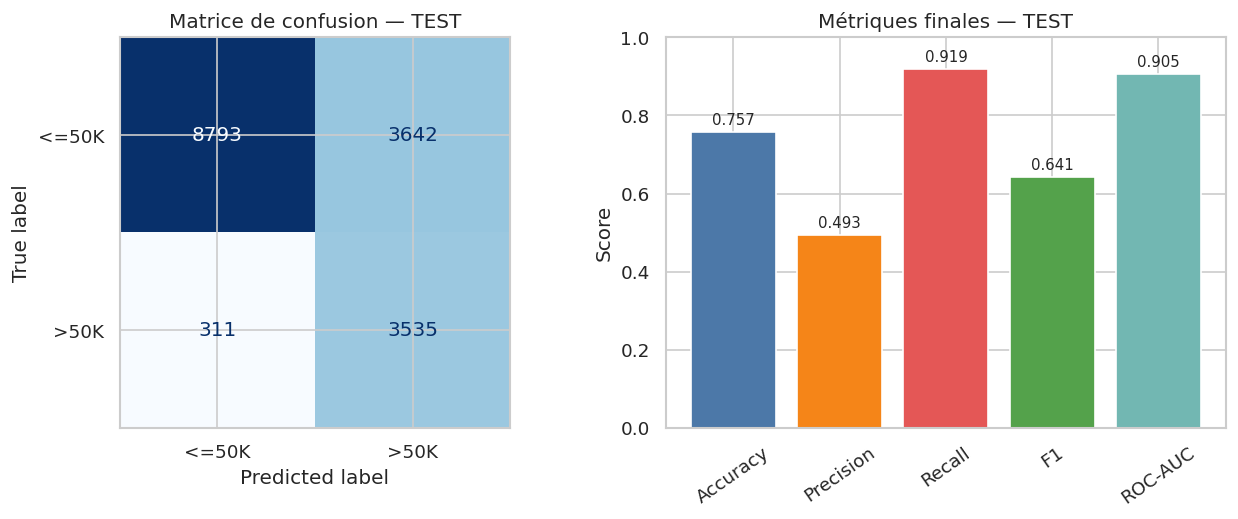

In [6]:
# Votre travail expérimental ici
test_raw = pd.read_csv(
    TEST_PATH,
    names=COLUMNS,
    sep=",",
    skipinitialspace=True,
    na_values="?",
    skiprows=1,  # adult.test commence par une ligne de commentaire
)
test_raw["income"] = test_raw["income"].str.strip().str.rstrip(".")
if not set(test_raw["income"].dropna().unique()).issubset({"<=50K", ">50K"}):
    raise ValueError("Libellés de cible inattendus dans adult.test")

X_test = test_raw.drop(columns="income")
y_test = (test_raw["income"] == ">50K").astype(int)

final_estimator = clone(models[selected_model_name])
final_pipeline = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", final_estimator),
])

t0 = time.perf_counter()
final_pipeline.fit(X_dev, y_dev)
final_fit_seconds = time.perf_counter() - t0

t0 = time.perf_counter()
test_scores, final_score_kind, _ = continuous_scores(final_pipeline, X_test)
test_pred = (test_scores >= selected_threshold).astype(int)
final_predict_seconds = time.perf_counter() - t0

test_business = business_metrics(y_test, test_pred)
final_metrics = pd.DataFrame([{
    "Modèle": selected_model_name,
    "Seuil figé": selected_threshold,
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_scores),
    "TN": test_business["TN"], "FP": test_business["FP"],
    "FN": test_business["FN"], "TP": test_business["TP"],
    "Coût = FP + 5×FN": test_business["Coût = FP + 5×FN"],
    "Fit final (s)": final_fit_seconds,
    "Prédiction TEST (s)": final_predict_seconds,
}]).set_index("Modèle")

print(f"TEST officiel : {len(test_raw):,} lignes ; classe positive : {100*y_test.mean():.2f} %.")
display(final_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["<=50K", ">50K"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Matrice de confusion — TEST")

metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
axes[1].bar(metric_names, final_metrics.iloc[0][metric_names].astype(float), color=["#4C78A8", "#F58518", "#E45756", "#54A24B", "#72B7B2"])
axes[1].set(title="Métriques finales — TEST", ylim=(0, 1), ylabel="Score")
axes[1].tick_params(axis="x", rotation=35)
for i, value in enumerate(final_metrics.iloc[0][metric_names].astype(float)):
    axes[1].text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)
plt.tight_layout()

fm = final_metrics.iloc[0]
print("\nDÉCISION ET LIMITES")
print(f"- Le modèle final est {selected_model_name} avec le seuil {selected_threshold:.4f}, choisi avant l'ouverture de TEST.")
print(f"- Sur TEST : recall={fm['Recall']:.3f}, precision={fm['Precision']:.3f}, F1={fm['F1']:.3f}, ROC-AUC={fm['ROC-AUC']:.3f}.")
print(f"- Le coût observé est {int(fm['Coût = FP + 5×FN'])} = {int(fm['FP'])} FP + 5×{int(fm['FN'])} FN.")
print("- Le seuil réduit le risque de faux négatifs au prix d'un plus grand nombre de faux positifs ; ce compromis est explicite et mesurable.")
print("- Un déploiement automatique n'est pas acceptable sans validation temporelle/externe, suivi des dérives, audit d'équité et recours humain.")
print("- Les variables démographiques sont sensibles et le revenu Adult date de 1994 : les résultats ne doivent pas être assimilés à une règle causale ou actuelle.")

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.